In [1]:
import os
import sys
import warnings
import subprocess
import pkgutil

warnings.filterwarnings("ignore")

for package in ["shap", "lime"]:
    if pkgutil.find_loader(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.inspection import permutation_importance

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
DATA_PATH = "/content/diabetes_012_health_indicators_BRFSS2015.csv"

if not os.path.exists(DATA_PATH):
    print("File not found. Please upload the CSV file, then update DATA_PATH.")
else:
    df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
print("Shape before cleaning:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().to_frame("Missing Values"))

print("\nDuplicated rows:", df.duplicated().sum())

Shape before cleaning: (140384, 22)

Columns:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Missing values:


,Missing Values
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,1
Fruits,1



Duplicated rows: 10209


In [4]:
df = df.copy()
df.columns = df.columns.str.strip()

if "Diabetes_binary" not in df.columns:
    if "Diabetes_012" in df.columns:
        df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 1 if x in [1, 2] else 0).astype(int)
    else:
        raise ValueError("No target column found. Expected Diabetes_binary or Diabetes_012.")

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.drop_duplicates().reset_index(drop=True)

binary_cols = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
    "DiffWalk", "Sex", "Diabetes_binary"
]

for col in binary_cols:
    if col in df.columns:
        df.loc[~df[col].isin([0, 1]), col] = np.nan

range_rules = {
    "BMI": (10, 100),
    "GenHlth": (1, 5),
    "MentHlth": (0, 30),
    "PhysHlth": (0, 30),
    "Age": (1, 13),
    "Education": (1, 6),
    "Income": (1, 8),
}

for col, (low, high) in range_rules.items():
    if col in df.columns:
        df.loc[~df[col].between(low, high), col] = np.nan

df = df.dropna(subset=["Diabetes_binary"]).reset_index(drop=True)
df["Diabetes_binary"] = df["Diabetes_binary"].astype(int)

print("Shape after cleaning:", df.shape)

print("\nTarget distribution:")
display(df["Diabetes_binary"].value_counts().sort_index().to_frame("Count"))

display(
    (df["Diabetes_binary"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .to_frame("Percentage")
)

Shape after cleaning: (130175, 23)

Target distribution:


,Count
Diabetes_binary,
0,108226
1,21949


,Percentage
Diabetes_binary,
0,83.14
1,16.86


In [5]:
if "BMI" in df.columns and "Age" in df.columns:
    df["BMI_Age"] = df["BMI"] * df["Age"]

risk_cols = ["HighBP", "HighChol", "HeartDiseaseorAttack", "Stroke", "DiffWalk"]
existing_risk_cols = [col for col in risk_cols if col in df.columns]

df["Health_Risk_Score"] = df[existing_risk_cols].fillna(0).sum(axis=1)

lifestyle_positive = [col for col in ["PhysActivity", "Fruits", "Veggies"] if col in df.columns]
lifestyle_negative = [col for col in ["Smoker", "HvyAlcoholConsump"] if col in df.columns]

df["Lifestyle_Score"] = (
    df[lifestyle_positive].fillna(0).sum(axis=1)
    - df[lifestyle_negative].fillna(0).sum(axis=1)
)

if "MentHlth" in df.columns and "PhysHlth" in df.columns:
    df["Poor_Health_Days"] = df["MentHlth"].fillna(0) + df["PhysHlth"].fillna(0)

print("Shape after feature engineering:", df.shape)
display(df.head())

Shape after feature engineering: (130175, 27)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,BMI_Age,Health_Risk_Score,Lifestyle_Score,Poor_Health_Days
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,0,360.0,3.0,0.0,33.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,0,175.0,0.0,0.0,0.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,0,252.0,3.0,1.0,60.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,0,297.0,1.0,3.0,0.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,0,264.0,2.0,3.0,3.0


In [6]:
target = "Diabetes_binary"

leakage_columns = [
    "Diabetes_binary",
    "Diabetes_012"
]

X = df.drop(columns=leakage_columns, errors="ignore")
y = df[target].astype(int)

print("Target column:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

feature_info = pd.DataFrame({
    "Feature": X.columns,
    "Dtype": X.dtypes.astype(str),
    "Unique Values": X.nunique().values,
    "Missing Values": X.isna().sum().values
})

display(feature_info)

Target column: Diabetes_binary
X shape: (130175, 25)
y shape: (130175,)


,Feature,Dtype,Unique Values,Missing Values
HighBP,HighBP,float64,2,0
HighChol,HighChol,float64,2,0
CholCheck,CholCheck,float64,2,0
BMI,BMI,float64,81,0
Smoker,Smoker,float64,2,0
Stroke,Stroke,float64,2,0
HeartDiseaseorAttack,HeartDiseaseorAttack,float64,2,0
PhysActivity,PhysActivity,float64,2,1
Fruits,Fruits,float64,2,1
Veggies,Veggies,float64,2,1


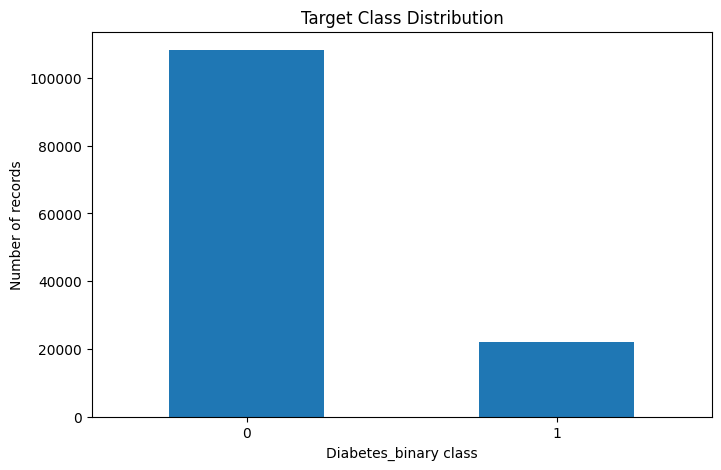

,Count,Percentage
Diabetes_binary,,
0,108226,83.14
1,21949,16.86


In [7]:
class_counts = y.value_counts().sort_index()
class_percent = (class_counts / class_counts.sum() * 100).round(2)

ax = class_counts.plot(kind="bar", title="Target Class Distribution")
ax.set_xlabel("Diabetes_binary class")
ax.set_ylabel("Number of records")
plt.xticks(rotation=0)
plt.show()

summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent
})

display(summary)

In [8]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
HighBP,130175.0,0.449034,0.497398,0.0,0.0,0.0,1.0,1.0
HighChol,130175.0,0.439585,0.496339,0.0,0.0,0.0,1.0,1.0
CholCheck,130175.0,0.960085,0.195761,0.0,1.0,1.0,1.0,1.0
BMI,130175.0,28.702539,7.085772,12.0,24.0,27.0,32.0,98.0
Smoker,130175.0,0.464989,0.498775,0.0,0.0,0.0,1.0,1.0
Stroke,130175.0,0.044310,0.205783,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,130175.0,0.100257,0.300344,0.0,0.0,0.0,0.0,1.0
PhysActivity,130174.0,0.741953,0.437562,0.0,0.0,1.0,1.0,1.0
Fruits,130174.0,0.620339,0.485304,0.0,0.0,1.0,1.0,1.0
Veggies,130174.0,0.797079,0.402176,0.0,1.0,1.0,1.0,1.0


Correlation between features and Diabetes_binary:


,Correlation with Diabetes_binary
Health_Risk_Score,0.337306
GenHlth,0.284986
BMI_Age,0.281295
HighBP,0.262646
DiffWalk,0.211343
HighChol,0.205018
BMI,0.201822
Age,0.182208
HeartDiseaseorAttack,0.170543
PhysHlth,0.162847


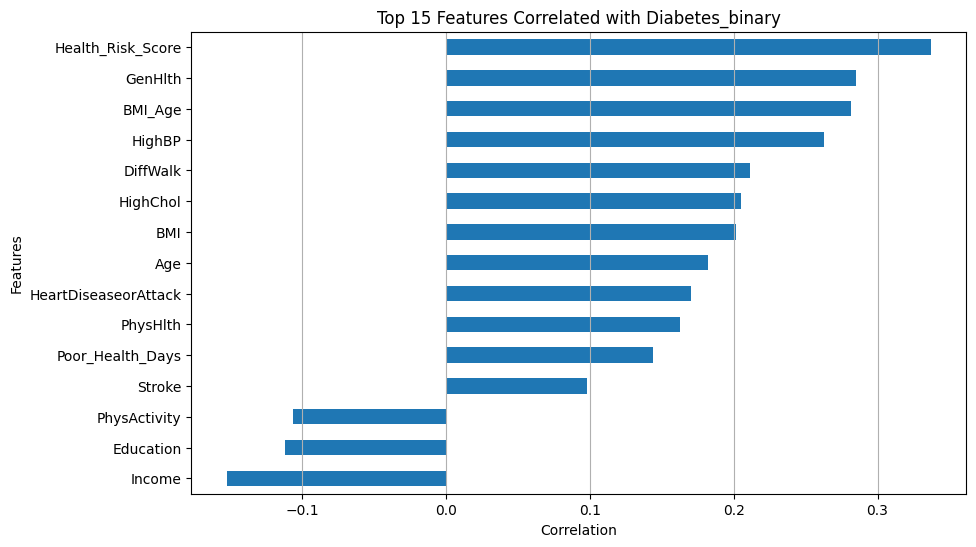

In [9]:
correlation_df = df.drop(columns=["Diabetes_012"], errors="ignore")

correlation_with_target = correlation_df.corr(numeric_only=True)["Diabetes_binary"]
correlation_with_target = correlation_with_target.drop("Diabetes_binary", errors="ignore")

correlation_with_target = correlation_with_target.reindex(
    correlation_with_target.abs().sort_values(ascending=False).index
)

corr_with_target = correlation_with_target

print("Correlation between features and Diabetes_binary:")
display(correlation_with_target.to_frame("Correlation with Diabetes_binary"))

plt.figure(figsize=(10, 6))
correlation_with_target.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Features Correlated with Diabetes_binary")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.grid(axis="x")
plt.show()

Features plotted: ['Health_Risk_Score', 'GenHlth', 'BMI_Age', 'HighBP', 'DiffWalk', 'HighChol']


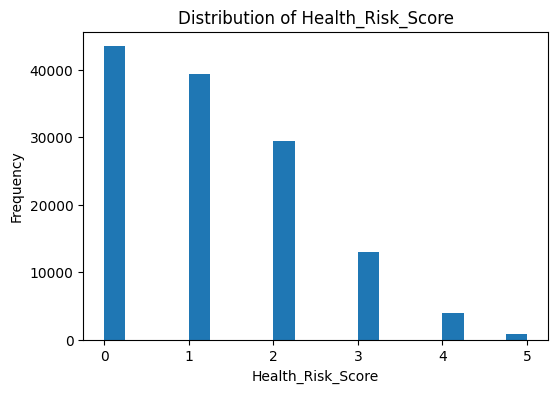

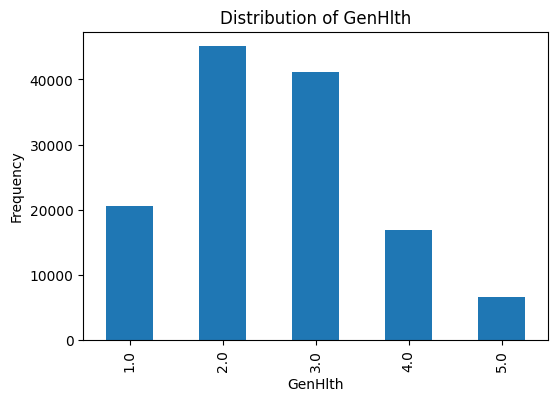

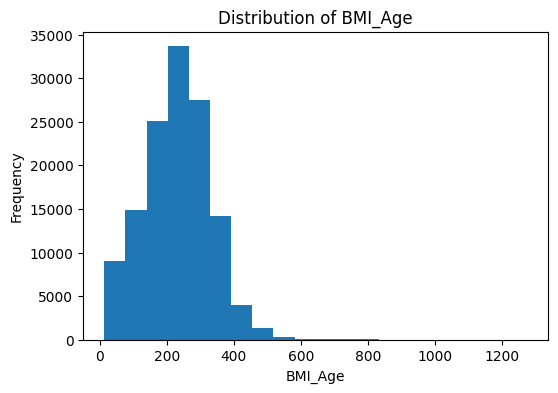

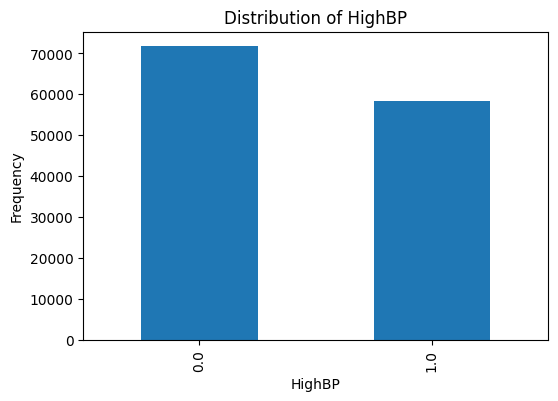

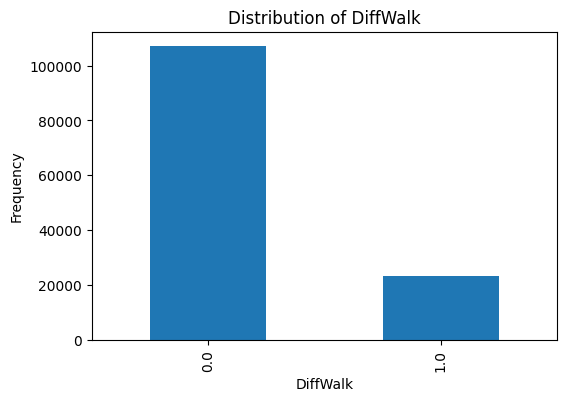

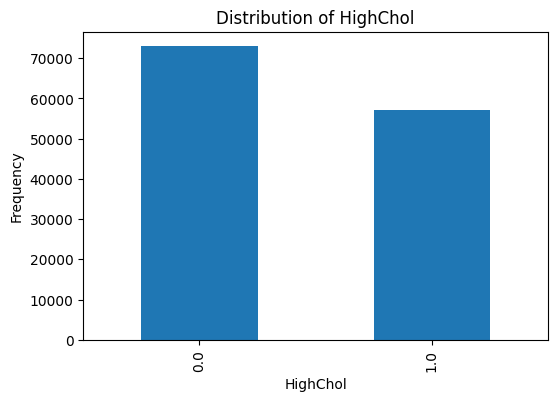

In [10]:
top_distribution_features = (
    correlation_with_target
    .drop(labels=["Diabetes_binary", "Diabetes_012"], errors="ignore")
    .head(6)
    .index
    .tolist()
)

top_distribution_features = [feature for feature in top_distribution_features if feature in X.columns]

print("Features plotted:", top_distribution_features)

for feature in top_distribution_features:
    plt.figure(figsize=(6, 4))

    if X[feature].nunique() <= 5:
        X[feature].value_counts().sort_index().plot(kind="bar")
    else:
        X[feature].dropna().hist(bins=20)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.grid(False)
    plt.show()

In [11]:
binary_features = [col for col in X.columns if X[col].dropna().nunique() <= 2]
numeric_features = [col for col in X.columns if col not in binary_features]

print("Binary features:", binary_features)
print("\nNumerical features:", numeric_features)
print("\nNumber of binary features:", len(binary_features))
print("Number of numerical features:", len(numeric_features))

Binary features: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Numerical features: ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income', 'BMI_Age', 'Health_Risk_Score', 'Lifestyle_Score', 'Poor_Health_Days']

Number of binary features: 14
Number of numerical features: 11


In [12]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)

print("\nTraining target proportion:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("Train Proportion"))

print("\nTesting target proportion:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("Test Proportion"))

X_train_raw: (104140, 25)
X_test_raw : (26035, 25)

Training target proportion:


,Train Proportion
Diabetes_binary,
0,0.83139
1,0.16861



Testing target proportion:


,Test Proportion
Diabetes_binary,
0,0.831381
1,0.168619


In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("binary", binary_transformer, binary_features),
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

feature_names = numeric_features + binary_features

X_train = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_raw.index
)

X_test = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test_raw.index
)

print("Processed X_train:", X_train.shape)
print("Processed X_test :", X_test.shape)
display(X_train.head())

Processed X_train: (104140, 25)
Processed X_test : (26035, 25)


,BMI,GenHlth,MentHlth,PhysHlth,Age,Education,Income,BMI_Age,Health_Risk_Score,Lifestyle_Score,Poor_Health_Days,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex
107710,24.0,2.0,0.0,2.0,2.0,4.0,6.0,48.0,0.0,-1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
125860,33.0,2.0,0.0,14.0,11.0,6.0,8.0,363.0,1.0,2.0,14.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
25332,25.0,1.0,0.0,0.0,13.0,2.0,1.0,325.0,2.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2775,31.0,5.0,30.0,27.0,8.0,4.0,5.0,248.0,3.0,1.0,57.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0
16739,27.0,4.0,0.0,0.0,1.0,5.0,4.0,27.0,2.0,3.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0


In [14]:
feature_selector_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=RANDOM_STATE
)

feature_selector_model.fit(X_train, y_train)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_selector_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance_df)

print("Important note: We will NOT reduce the model to only 6 features.")
print("Using all cleaned features usually gives better performance.")

,Feature,Importance
8,Health_Risk_Score,0.565098
1,GenHlth,0.170162
0,BMI,0.154982
7,BMI_Age,0.109759
2,MentHlth,0.000000
4,Age,0.000000
3,PhysHlth,0.000000
6,Income,0.000000
5,Education,0.000000
9,Lifestyle_Score,0.000000


Important note: We will NOT reduce the model to only 6 features.
Using all cleaned features usually gives better performance.


In [15]:
def evaluate_classifier(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

    display(pd.DataFrame([metrics]).round(4))

    print("Classification Report:\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    ))

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["No Diabetes", "Diabetes"]
    )
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{model_name} — ROC Curve")
    plt.show()

    return metrics


def plot_top_importances(importances, names, title, top_n=15):
    importance_df = pd.DataFrame({
        "Feature": list(names),
        "Importance": list(importances)
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    ).reset_index(drop=True)

    plot_df = importance_df.head(top_n).sort_values("Importance")

    ax = plot_df.plot(
        kind="barh",
        x="Feature",
        y="Importance",
        legend=False,
        title=title
    )

    ax.set_xlabel("Importance")
    plt.show()

    return importance_df


def get_binary_shap_values(model, X_sample):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    if isinstance(shap_values, list):
        return shap_values[1] if len(shap_values) > 1 else shap_values[0]

    shap_array = np.array(shap_values)

    if shap_array.ndim == 3:
        if shap_array.shape[2] > 1:
            return shap_array[:, :, 1]
        if shap_array.shape[0] > 1:
            return shap_array[1]

    return shap_array

In [16]:
base_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

param_distributions = {
    "criterion": ["gini", "entropy"],
    "max_depth": [4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 10, 30, 50],
    "min_samples_leaf": [10, 20, 50, 100],
    "class_weight": [None, "balanced"]
}

tree_search = RandomizedSearchCV(
    estimator=base_tree,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

tree_search.fit(X_train, y_train)

model = tree_search.best_estimator_

print("Best parameters:")
print(tree_search.best_params_)

print("\nBest CV accuracy:", round(tree_search.best_score_, 4))
print("\nDecision Tree training completed.")
print(model)

Best parameters:
{'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': 6, 'criterion': 'gini', 'class_weight': None}

Best CV accuracy: 0.8379

Decision Tree training completed.
DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, min_samples_split=10,
                       random_state=42)


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Improved Decision Tree,0.8374,0.575,0.138,0.2226,0.7981


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.85      0.98      0.91     21645
    Diabetes       0.57      0.14      0.22      4390

    accuracy                           0.84     26035
   macro avg       0.71      0.56      0.57     26035
weighted avg       0.80      0.84      0.79     26035



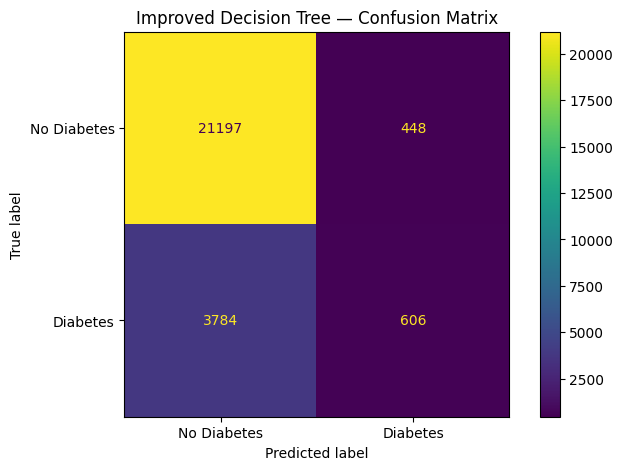

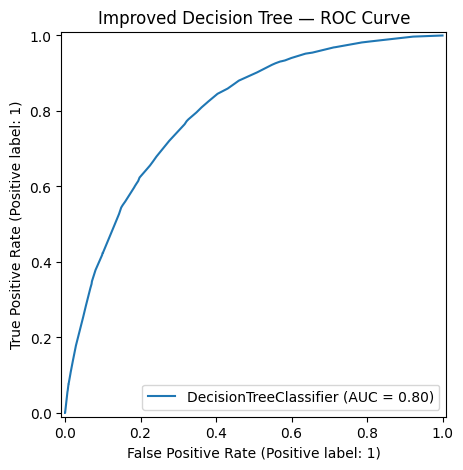

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [17]:
dt_metrics = evaluate_classifier(
    model,
    X_test,
    y_test,
    "Improved Decision Tree"
)

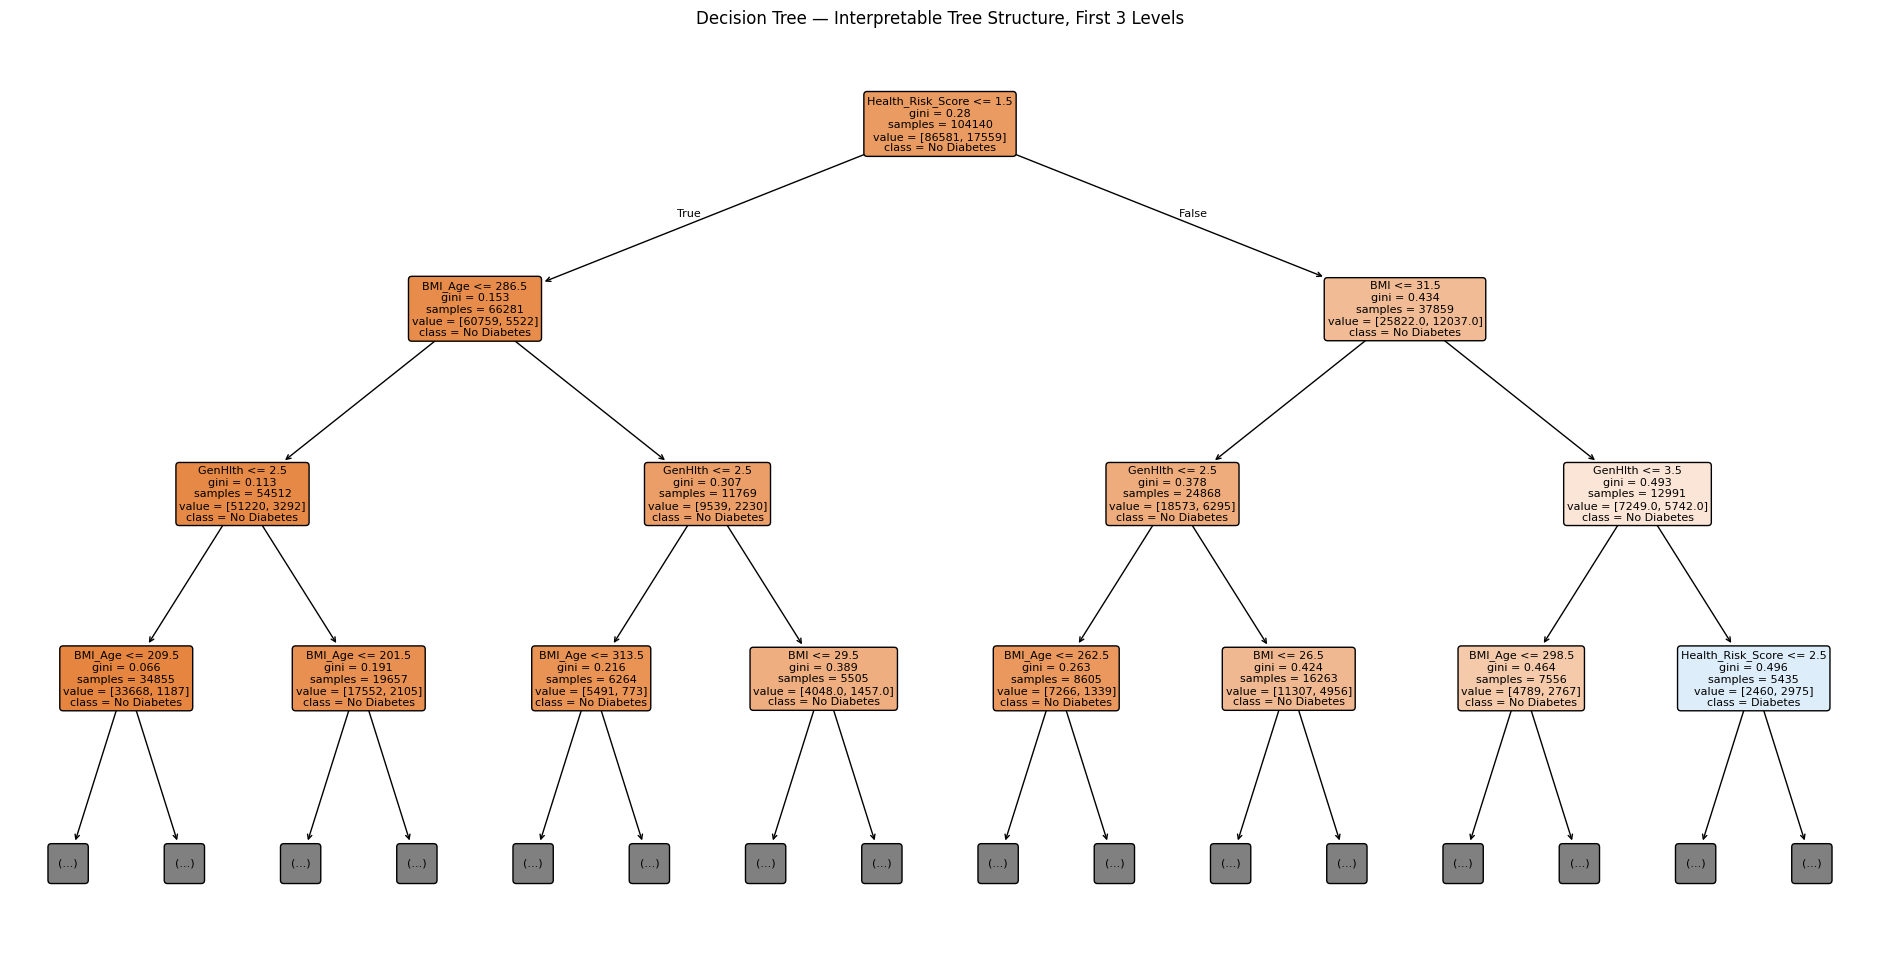

In [18]:
plt.figure(figsize=(24, 12))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree — Interpretable Tree Structure, First 3 Levels")
plt.show()

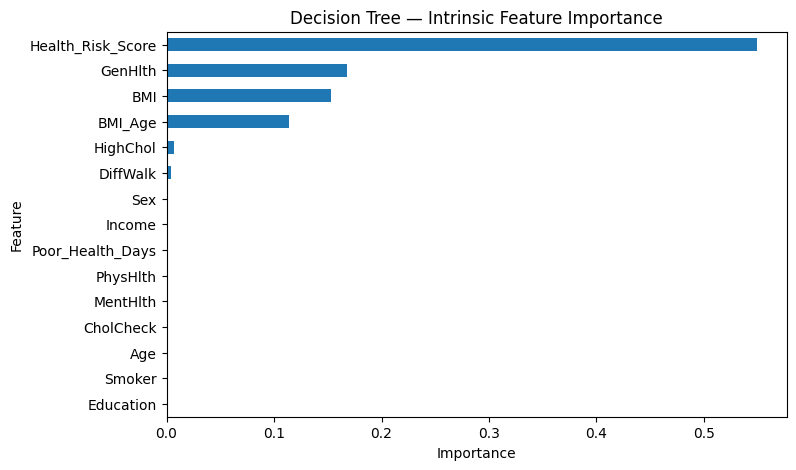

,Feature,Importance
0,Health_Risk_Score,0.549348
1,GenHlth,0.167600
2,BMI,0.153341
3,BMI_Age,0.113647
4,HighChol,0.006509
5,DiffWalk,0.004495
6,Sex,0.001407
7,Income,0.000937
8,Poor_Health_Days,0.000631
9,PhysHlth,0.000624


In [20]:
intrinsic_importance_df = plot_top_importances(
    model.feature_importances_,
    feature_names,
    "Decision Tree — Intrinsic Feature Importance"
)

display(intrinsic_importance_df)

,Feature,Mean Importance,Std
8,Health_Risk_Score,0.091331,0.002549
1,GenHlth,0.048038,0.002412
7,BMI_Age,0.039069,0.001378
0,BMI,0.022540,0.001179
12,HighChol,0.002042,0.000439
6,Income,0.000476,0.000099
13,CholCheck,0.000278,0.000135
24,Sex,0.000273,0.000269
2,MentHlth,0.000225,0.000119
3,PhysHlth,0.000161,0.000278


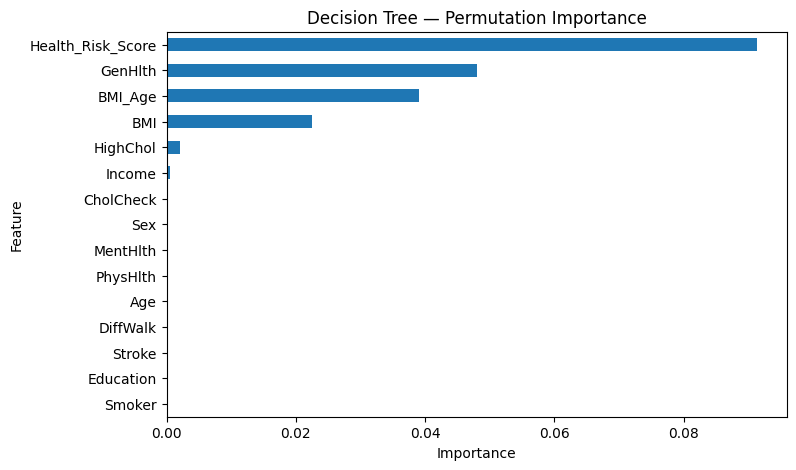

,Feature,Importance
0,Health_Risk_Score,0.091331
1,GenHlth,0.048038
2,BMI_Age,0.039069
3,BMI,0.022540
4,HighChol,0.002042
5,Income,0.000476
6,CholCheck,0.000278
7,Sex,0.000273
8,MentHlth,0.000225
9,PhysHlth,0.000161


In [21]:
perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
}).sort_values("Mean Importance", ascending=False)

display(permutation_importance_df)

plot_top_importances(
    permutation_importance_df["Mean Importance"].values,
    permutation_importance_df["Feature"].values,
    "Decision Tree — Permutation Importance"
)

PDP features: ['Health_Risk_Score', 'GenHlth', 'BMI_Age']


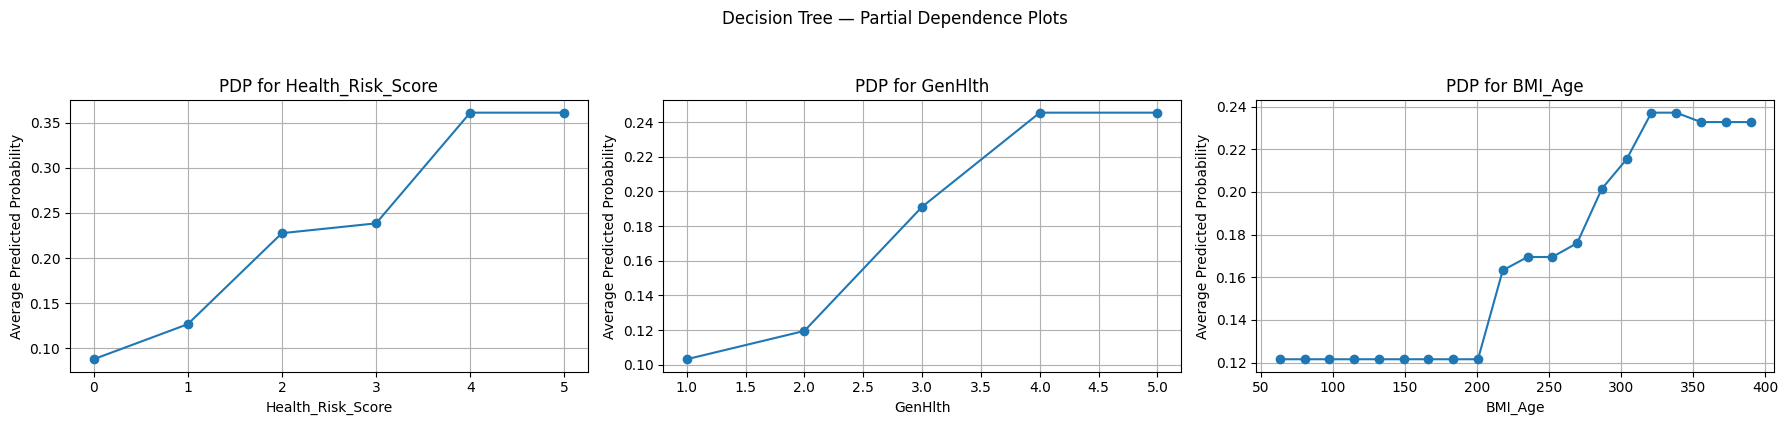

In [22]:
top_pdp_features = permutation_importance_df.head(3)["Feature"].tolist()
top_pdp_features = [feature for feature in top_pdp_features if feature in X_test.columns]

print("PDP features:", top_pdp_features)

if len(top_pdp_features) > 0:
    fig, axes = plt.subplots(
        1,
        len(top_pdp_features),
        figsize=(6 * len(top_pdp_features), 4)
    )

    if len(top_pdp_features) == 1:
        axes = [axes]

    for ax, feature in zip(axes, top_pdp_features):
        unique_values = np.sort(X_test[feature].dropna().unique())

        if len(unique_values) > 20:
            grid_values = np.linspace(
                X_test[feature].quantile(0.05),
                X_test[feature].quantile(0.95),
                20
            )
        else:
            grid_values = unique_values

        pdp_values = []

        for value in grid_values:
            X_temp = X_test.copy()
            X_temp[feature] = value

            predictions = model.predict_proba(X_temp)[:, 1]
            pdp_values.append(np.mean(predictions))

        ax.plot(grid_values, pdp_values, marker="o")
        ax.set_title(f"PDP for {feature}")
        ax.set_xlabel(feature)
        ax.set_ylabel("Average Predicted Probability")
        ax.grid(True)

    plt.suptitle("Decision Tree — Partial Dependence Plots", y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("No valid PDP features found.")

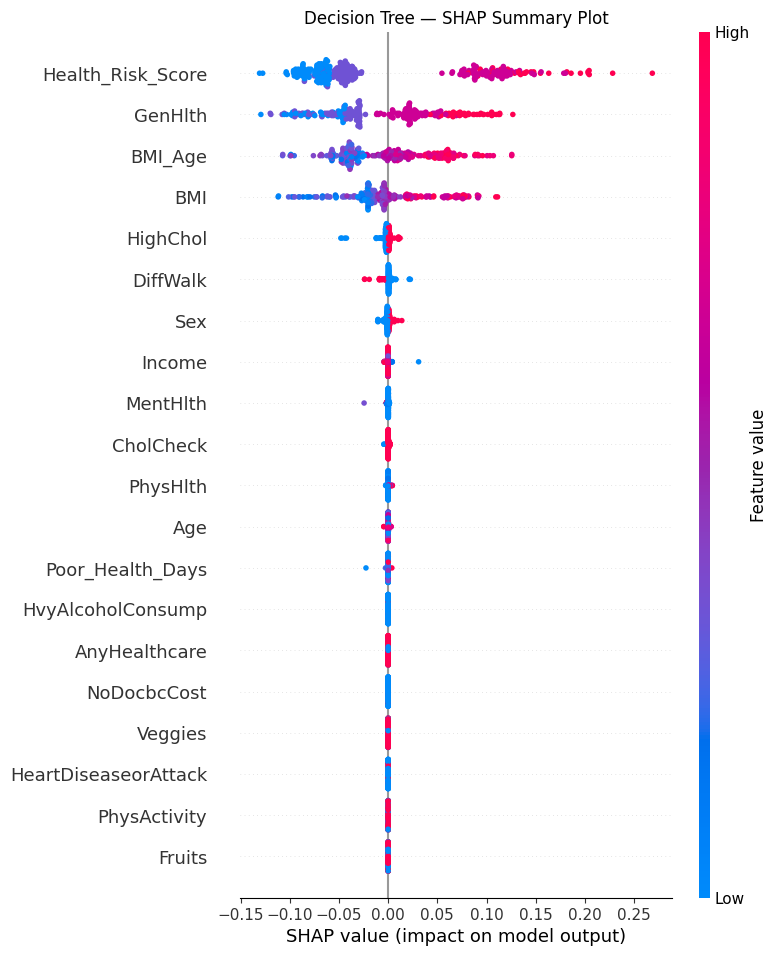

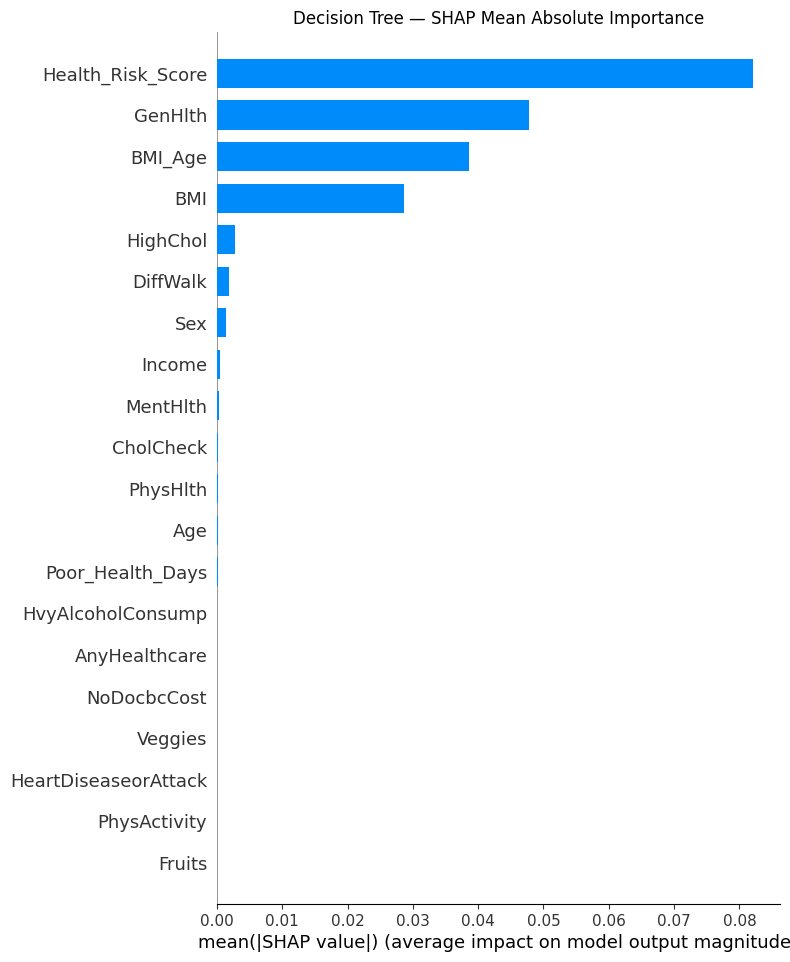

In [23]:
X_shap = X_test.sample(
    n=min(300, len(X_test)),
    random_state=RANDOM_STATE
)

shap_values_to_plot = get_binary_shap_values(model, X_shap)

shap.summary_plot(
    shap_values_to_plot,
    X_shap,
    show=False
)

plt.title("Decision Tree — SHAP Summary Plot")
plt.show()

shap.summary_plot(
    shap_values_to_plot,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title("Decision Tree — SHAP Mean Absolute Importance")
plt.show()

Explained test instance index: 0
True class: 0
Predicted probabilities [No Diabetes, Diabetes]: [0.54972642 0.45027358]


,Feature Condition,Local Weight
0,1.00 < Health_Risk_Score <= 2.00,0.087393
1,GenHlth > 3.00,0.084470
2,165.00 < BMI_Age <= 234.00,-0.040240
3,HvyAlcoholConsump <= 0.00,-0.009672
4,PhysHlth > 3.00,0.007789
5,27.00 < BMI <= 32.00,0.005914
6,0.00 < Smoker <= 1.00,-0.005601
7,Poor_Health_Days > 9.00,0.004976
8,Age <= 6.00,0.004080
9,DiffWalk > 0.00,-0.003916


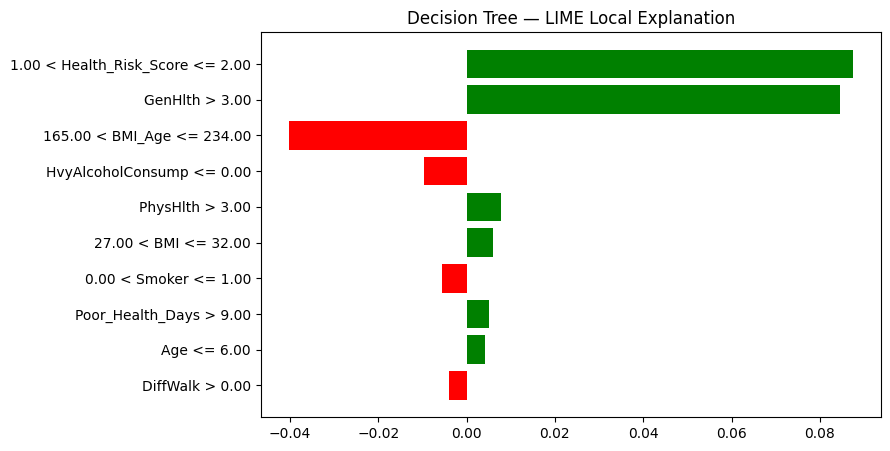

In [24]:
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    class_names=["No Diabetes", "Diabetes"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

instance_index = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[instance_index].values,
    predict_fn=model.predict_proba,
    num_features=10
)

print("Explained test instance index:", instance_index)
print("True class:", y_test.iloc[instance_index])
print(
    "Predicted probabilities [No Diabetes, Diabetes]:",
    model.predict_proba(X_test.iloc[[instance_index]])[0]
)

display(pd.DataFrame(
    lime_exp.as_list(),
    columns=["Feature Condition", "Local Weight"]
))

lime_exp.as_pyplot_figure()
plt.title("Decision Tree — LIME Local Explanation")
plt.show()

In [25]:
xai_comparison = pd.DataFrame({
    "XAI Tool": [
        "Tree Structure",
        "Decision Rules",
        "Intrinsic Feature Importance",
        "Permutation Importance",
        "PDP",
        "SHAP",
        "LIME"
    ],
    "Explanation Type": [
        "Global model structure",
        "Global readable logic",
        "Global feature ranking",
        "Global feature ranking",
        "Global feature effect",
        "Global + local contribution",
        "Local explanation"
    ],
    "Main Use": [
        "Shows how the model splits the data.",
        "Converts the tree into IF-THEN rules.",
        "Ranks features by impurity reduction.",
        "Measures performance drop after shuffling each feature.",
        "Shows average effect of features on diabetes probability.",
        "Shows direction and size of feature effects.",
        "Explains one individual prediction."
    ],
    "Limitation": [
        "Large trees can become hard to read.",
        "Rules become long when the tree is deep.",
        "Can be biased toward split-heavy variables.",
        "Can be unstable with correlated features.",
        "May hide interactions between features.",
        "Can be computationally heavier.",
        "Only explains one case at a time."
    ]
})

display(xai_comparison)

,XAI Tool,Explanation Type,Main Use,Limitation
0,Tree Structure,Global model structure,Shows how the model splits the data.,Large trees can become hard to read.
1,Decision Rules,Global readable logic,Converts the tree into IF-THEN rules.,Rules become long when the tree is deep.
2,Intrinsic Feature Importance,Global feature ranking,Ranks features by impurity reduction.,Can be biased toward split-heavy variables.
3,Permutation Importance,Global feature ranking,Measures performance drop after shuffling each...,Can be unstable with correlated features.
4,PDP,Global feature effect,Shows average effect of features on diabetes p...,May hide interactions between features.
5,SHAP,Global + local contribution,Shows direction and size of feature effects.,Can be computationally heavier.
6,LIME,Local explanation,Explains one individual prediction.,Only explains one case at a time.
